In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Dataset.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
print("\nShape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head())


Shape of dataset: (1092, 10)

Columns: ['timestamp', 'region', 'service_line', 'resource_demand', 'capacity_planned', 'operational_spend_usd', 'reliability_score', 'gdp_growth_rate', 'tech_investment_index', 'cloud_sentiment_score']

First 3 rows:
     timestamp         region service_line  resource_demand  capacity_planned  \
0  2024-01-01        East US      Compute           644.69               818   
1  2024-01-01        East US      Storage          1102.71              1400   
2  2024-01-01    West Europe      Compute           597.55               758   
3  2024-01-01    West Europe      Storage           979.71              1244   
4  2024-01-01  Central India      Compute           503.19               639   

   operational_spend_usd  reliability_score  gdp_growth_rate  \
0                 361.03             99.804             2.06   
1                 154.38             99.571             2.06   
2                 334.63             99.727             2.08   
3            

In [6]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 timestamp                 0
region                    0
service_line              0
resource_demand          22
capacity_planned          0
operational_spend_usd     0
reliability_score         0
gdp_growth_rate          22
tech_investment_index    22
cloud_sentiment_score     0
dtype: int64


In [7]:
# Fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df = df.drop_duplicates()
print("\nDuplicates removed")


Duplicates removed


In [9]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
print("\nColumn names standardized")


Column names standardized


In [10]:
for col in df.columns:
    if "date" in col or "time" in col:
        df[col] = pd.to_datetime(df[col])

In [12]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df = df[df[col] >= 0]

print("Negative values removed successfully")


Negative values removed successfully


In [13]:
for col in df.columns:
    if "date" in col or "time" in col:
        df["year"] = df[col].dt.year
        df["month"] = df[col].dt.month
        df["day"] = df[col].dt.day



Before Cleaning Summary:
                 timestamp  resource_demand  capacity_planned  \
count                 1092      1092.000000       1092.000000   
mean   2024-03-31 12:00:00       784.407958        992.684982   
min    2024-01-01 00:00:00       466.190000        592.000000   
25%    2024-02-15 00:00:00       581.420000        735.000000   
50%    2024-03-31 12:00:00       811.350000        956.000000   
75%    2024-05-16 00:00:00       976.637500       1241.000000   
max    2024-06-30 00:00:00      1168.180000       1483.000000   
std                    NaN       221.722926        284.752144   

       operational_spend_usd  reliability_score  gdp_growth_rate  \
count            1092.000000        1092.000000      1092.000000   
mean              231.490394          99.704892         2.179643   
min               112.690000          99.400000         1.850000   
25%               136.880000          99.561000         2.080000   
50%               212.305000          99.708500 

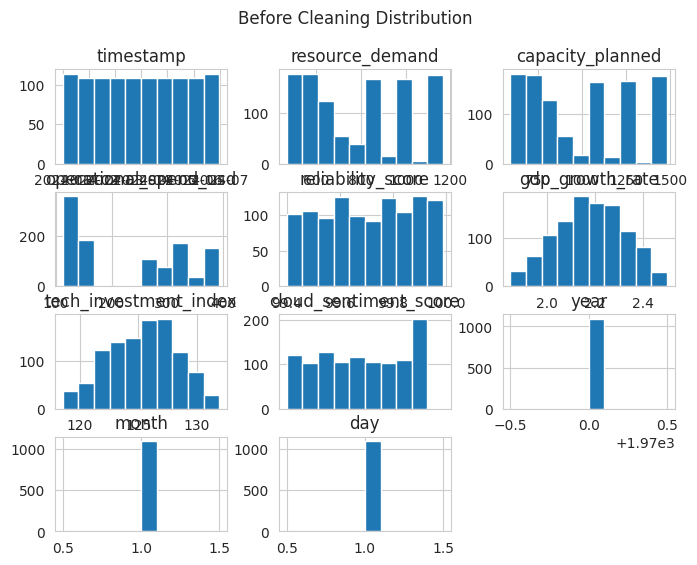

In [14]:
print("\nBefore Cleaning Summary:")
print(df.describe())

df.hist(figsize=(8,6))
plt.suptitle("Before Cleaning Distribution")
plt.show()



After Cleaning Summary:
                 timestamp  resource_demand  capacity_planned  \
count                 1092      1092.000000       1092.000000   
mean   2024-03-31 12:00:00       784.407958        992.684982   
min    2024-01-01 00:00:00       466.190000        592.000000   
25%    2024-02-15 00:00:00       581.420000        735.000000   
50%    2024-03-31 12:00:00       811.350000        956.000000   
75%    2024-05-16 00:00:00       976.637500       1241.000000   
max    2024-06-30 00:00:00      1168.180000       1483.000000   
std                    NaN       221.722926        284.752144   

       operational_spend_usd  reliability_score  gdp_growth_rate  \
count            1092.000000        1092.000000      1092.000000   
mean              231.490394          99.704892         2.179643   
min               112.690000          99.400000         1.850000   
25%               136.880000          99.561000         2.080000   
50%               212.305000          99.708500  

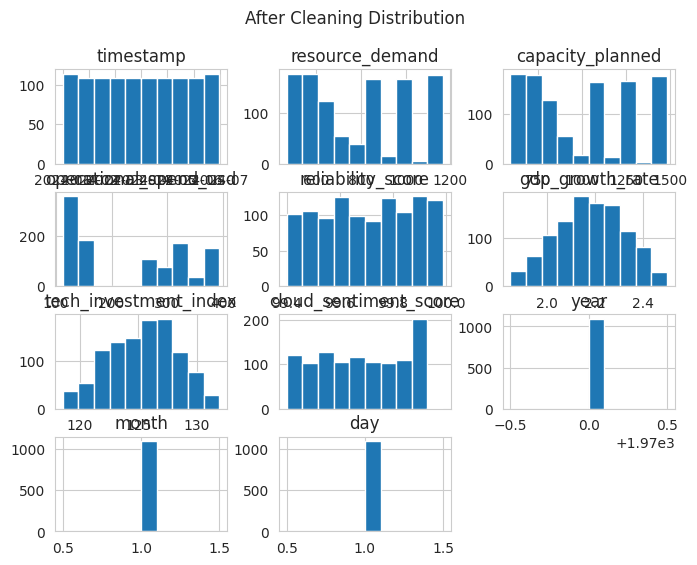

In [ ]:
print("\nAfter Cleaning Summary:")
print(df.describe())

df.hist(figsize=(8,6))
plt.suptitle("After Cleaning Distribution")
plt.show()


In [16]:
df.to_csv("cleaned_dataset.csv", index=False)
print("\nCleaned dataset saved successfully")


Cleaned dataset saved successfully
